**GIREESH V PAI**

DAV LAB MINI PROJECT

**REGISTRATION NUMBER: 251090052462**

**ROLL NUMBER: 59**

SECTION: PB

# Mini Project: Online Learning Engagement Analysis

### 1. Introduction
**Description of the Dataset:** The dataset utilized for this analysis is the **Online Learning Engagement Dataset**. It contains tracking metrics for virtual learners, capturing demographic details, technical resources (like internet speed and device type), study habits, and academic performance. 

**Objective of the analysis:**
The primary objective of this project is to analyze student engagement metrics and determine how factors like weekly study hours, quiz scores, and session durations impact a student's final grade. Furthermore, the analysis aims to identify the key behavioral patterns that contribute to a student dropping out of the course.

### 2. Dataset Description
* **Source of dataset:** Custom/Kaggle Online Learning Engagement Dataset (`online_learning_engagement_dataset.csv`)
* **Number of records and attributes:** The dataset contains 50,000 records (rows) and 18 attributes (columns).
* **Important variables used in analysis:** `study_hours_weekly`, `engagement_score`, `dropout`, `avg_quiz_score`, `device_type`, and `final_grade`.

**Q1:Structure and basic overview of the dataset**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\MAHE\OneDrive - Manipal Academy of Higher Education\Desktop\DataScience\davproject.csv")

print(df.head())
print(df.shape)
print(df.columns)

   student_id  age  gender    country device_type  internet_speed_mbps  \
0           1   24  Female        USA      Laptop                44.70   
1           2   37  Female    Germany      Tablet                61.10   
2           3   46  Female  Australia      Tablet                43.10   
3           4   32    Male      India      Tablet                26.99   
4           5   28    Male      India      Laptop                52.28   

   study_hours_weekly  login_frequency_weekly  avg_session_duration_min  \
0               15.92                      10                 40.052752   
1                6.37                       8                 32.442671   
2                6.64                       7                 43.614509   
3               10.91                       5                 30.697263   
4                7.41                       6                 47.402999   

   video_watch_time_min  assignments_submitted  forum_posts  quiz_attempts  \
0            294.099760   

**Q2:types of features exist in the dataset**

In [2]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

print("Numerical:", num_cols)
print("Categorical:", cat_cols)

Numerical: Index(['student_id', 'age', 'internet_speed_mbps', 'study_hours_weekly',
       'login_frequency_weekly', 'avg_session_duration_min',
       'video_watch_time_min', 'assignments_submitted', 'forum_posts',
       'quiz_attempts', 'avg_quiz_score', 'attendance_rate',
       'engagement_score', 'final_grade', 'dropout'],
      dtype='str')
Categorical: Index(['gender', 'country', 'device_type'], dtype='str')


Separating numerical and categorical features helps in choosing appropriate analysis techniques. For example, numerical data is used in correlation and histograms, while categorical data is used in grouping and comparison plots.

**Q3: Checking for missing values or data quality issues**

In [3]:
df.isnull().sum()

student_id                  0
age                         0
gender                      0
country                     0
device_type                 0
internet_speed_mbps         0
study_hours_weekly          0
login_frequency_weekly      0
avg_session_duration_min    0
video_watch_time_min        0
assignments_submitted       0
forum_posts                 0
quiz_attempts               0
avg_quiz_score              0
attendance_rate             0
engagement_score            0
final_grade                 0
dropout                     0
dtype: int64

**Q4: Checking for outliers in the dataset**

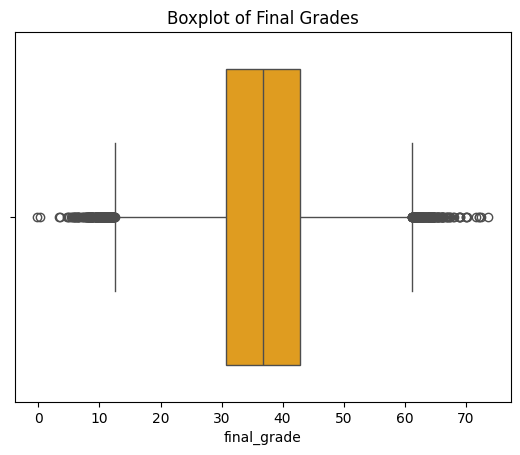

In [4]:
sns.boxplot(x=df['final_grade'],color='orange')
plt.title("Boxplot of Final Grades")
plt.show()

The boxplot reveals outliers in final grades.


box plot used because it clearly shows:

Median
Quartiles
Outliers

Other plots (like histograms) do not explicitly highlight outliers as effectively

**Q5. Categorizing students based on study behaviour**

In [5]:
bins = [0, 10, 20, 40]
labels = ['Low', 'Medium', 'High']

df['study_category'] = pd.cut(df['study_hours_weekly'], bins=bins, labels=labels)
df[['study_hours_weekly', 'study_category']]

,study_hours_weekly,study_category
0,15.92,Medium
1,6.37,Low
2,6.64,Low
3,10.91,Medium
4,7.41,Low
...,...,...
49995,16.67,Medium
49996,10.89,Medium
49997,13.02,Medium
49998,10.00,Low


Students are categorized based on their weekly study hours into Low, Medium, and High groups. This helps in simplifying continuous data into meaningful categories for better comparison and analysis.

**Q6. Overall student engagement**

In [6]:
df['engagement_score'] = df['login_frequency_weekly'] + df['forum_posts'] + df['video_watch_time_min']
print(df[['engagement_score']])

       engagement_score
0            308.099760
1            422.397658
2            211.239738
3            376.451629
4            161.341296
...                 ...
49995        341.570722
49996        387.638038
49997        376.872387
49998        608.282683
49999        333.477185

[50000 rows x 1 columns]




Combining multiple engagement metrics provides a single, meaningful indicator of student activity.


**Q7: Overall distribution of numerical features**

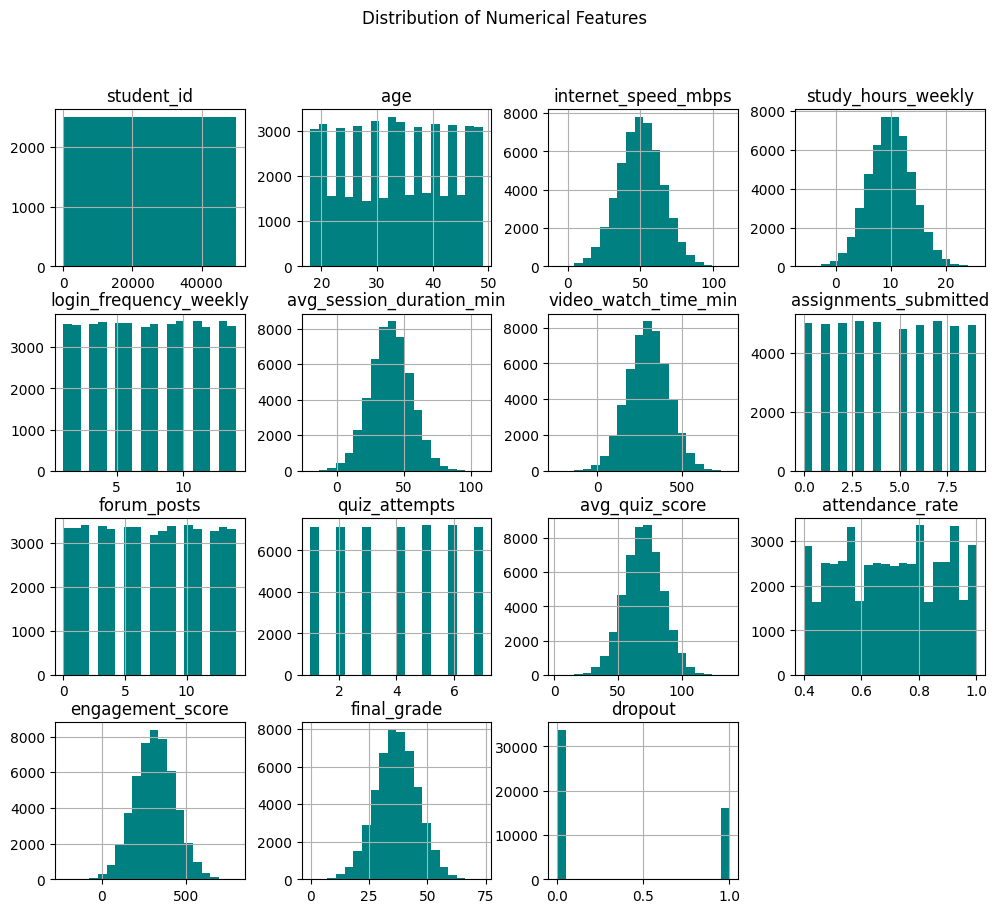

In [7]:
df.hist(figsize=(12,10), bins=20, color='teal')
plt.suptitle("Distribution of Numerical Features")
plt.show()

This shows how each numerical feature is distributed (normal, skewed, etc.).


a histogram is useed because it is the best way to understand frequency distribution and spread of data.

**Q8: Correlation of attributes**

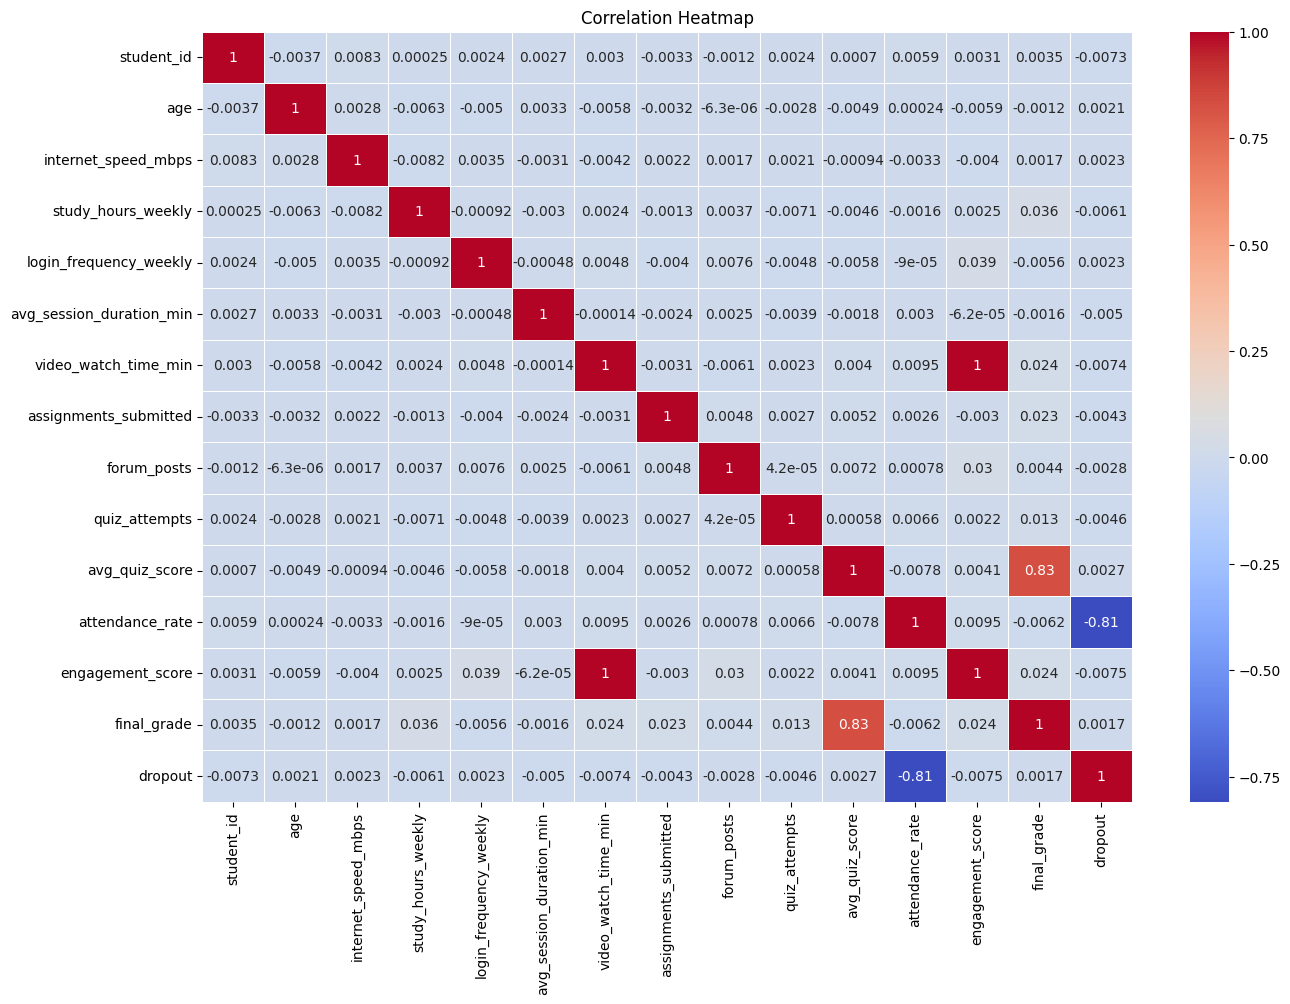

In [8]:
plt.figure(figsize=(15,10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True,cmap='coolwarm',linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

The heatmap shows relationships between variables.


A heat map is used because it visualizes multiple correlations at once, which is not possible with scatter plots individually.

**Q9. Features which most strongly affect final grades**

attendance_rate            -0.006209
login_frequency_weekly     -0.005579
avg_session_duration_min   -0.001580
age                        -0.001213
internet_speed_mbps         0.001650
dropout                     0.001737
student_id                  0.003482
forum_posts                 0.004365
quiz_attempts               0.013180
assignments_submitted       0.022913
engagement_score            0.023806
video_watch_time_min        0.023864
study_hours_weekly          0.036192
avg_quiz_score              0.830474
Name: final_grade, dtype: float64


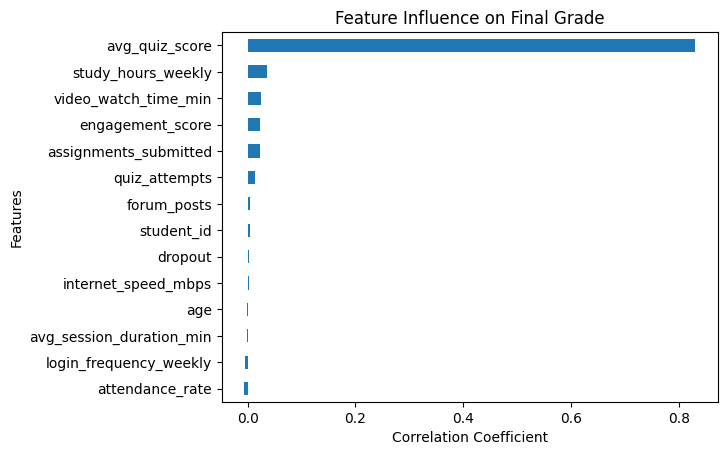

In [9]:

corr_target = df.corr(numeric_only=True)['final_grade'].drop('final_grade')
corr_target = corr_target.sort_values()
print(corr_target)
plt.figure()
corr_target.plot(kind='barh')

plt.title("Feature Influence on Final Grade")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")
plt.show()


This identifies the most influential variables.

 
Correlation analysis is used because it quantitatively measures strength of relationships.

The bar chart shows the correlation of different features with final grades. Engagement-related features and study hours exhibit strong positive correlations, indicating that they significantly impact student performance. Features with low correlation have minimal influence on final outcomes.

**Q10. Relationship between engagement and performance**

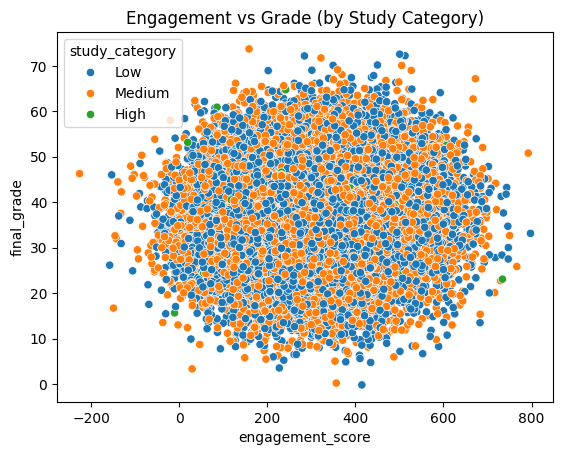

In [10]:
sns.scatterplot(x='engagement_score', y='final_grade', 
                hue='study_category', data=df)

plt.title("Engagement vs Grade (by Study Category)")
plt.show()


A positive trend indicates higher engagement leads to better grades.

A regression plot is used because it shows both scatter points and trend line, making relationships clearer.

**Q11. How do study habits influence performance?**

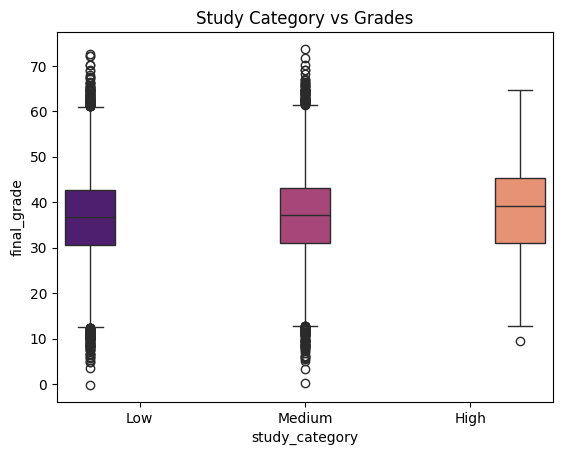

In [11]:
sns.boxplot(x='study_category', y='final_grade', data=df, palette='magma', 
            hue='study_category', legend=False, width=0.9)
plt.title("Study Category vs Grades")
plt.show()


Students with higher study hours perform better.


A box plot is used because it compares distributions across categories effectively.

**Q12. Are there students with unusual behavior patterns?**

In [12]:
df[(df['engagement_score'] > df['engagement_score'].mean()) & 
   (df['final_grade'] < df['final_grade'].mean())]

,student_id,age,gender,country,device_type,internet_speed_mbps,study_hours_weekly,login_frequency_weekly,avg_session_duration_min,video_watch_time_min,assignments_submitted,forum_posts,quiz_attempts,avg_quiz_score,attendance_rate,engagement_score,final_grade,dropout,study_category
9,10,43,Male,India,Mobile,57.90,13.04,12,51.732781,442.976482,9,14,3,70.69,0.57,468.976482,36.157768,1,Medium
19,20,20,Female,USA,Tablet,42.70,4.98,3,37.476155,297.871228,4,14,2,69.89,0.45,314.871228,32.328817,1,Low
21,22,38,Female,Canada,Mobile,66.30,17.00,14,68.033051,385.014584,8,9,4,74.82,0.80,408.014584,35.753271,0,Medium
22,23,19,Male,India,Tablet,63.45,9.39,8,43.320933,449.962666,3,9,6,48.98,0.91,466.962666,19.812989,0,Low
25,26,47,Female,Germany,Tablet,79.81,5.09,9,17.844675,357.642365,1,7,5,61.83,0.54,373.642365,33.839658,1,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49980,49981,30,Female,Canada,Laptop,47.65,6.48,12,42.062798,402.107546,0,8,6,64.23,0.83,422.107546,28.299745,0,Low
49982,49983,33,Female,Australia,Mobile,31.54,9.51,10,43.362195,357.126093,0,3,1,67.29,0.76,370.126093,30.439058,0,Low
49985,49986,47,Female,Australia,Mobile,73.14,10.40,12,50.916929,634.228971,9,6,2,50.84,0.54,652.228971,35.626636,1,Medium
49993,49994,28,Male,USA,Laptop,71.40,9.80,7,29.988874,502.303471,3,5,4,57.90,0.98,514.303471,35.576185,0,Low


Some students are engaged but still perform poorly.

Filtering helps because it helps identify specific patterns not visible in graphs.

**Q13: Gender distribution and how does performance vary across gender**

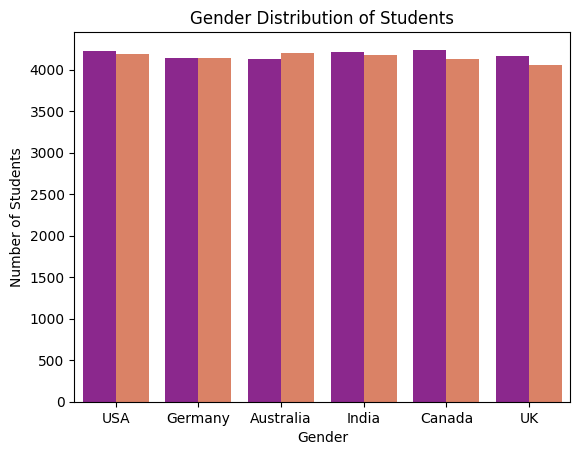

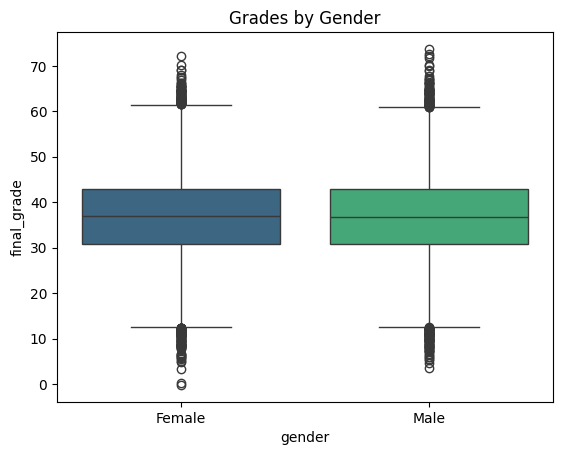

In [13]:
# Count plot for gender distribution by country
sns.countplot(x='country', data=df,palette='plasma',hue='gender', legend= False)

plt.title("Gender Distribution of Students")
plt.xlabel("Gender")
plt.ylabel("Number of Students")
plt.show()

sns.boxplot(x='gender', y='final_grade', data=df, palette='viridis', hue='gender', legend=False)
plt.title("Grades by Gender")
plt.show()

Shows variation in performance across groups.

Boxplot used instead of a bar chart
Because it shows spread, median, and outliers, not just average.

**Q14. How does average academic performance vary across different study categories?**

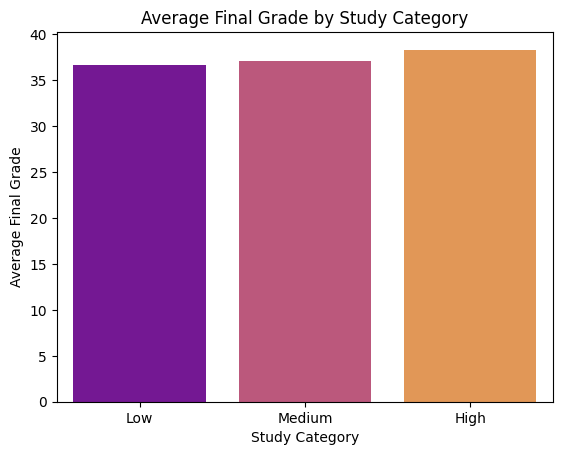

In [14]:

# Ensure study_category exists
avg_scores = df.groupby('study_category')['final_grade'].mean()

sns.barplot(x=avg_scores.index, y=avg_scores.values, palette='plasma', hue=avg_scores.index, legend=False, dodge=False)

plt.title("Average Final Grade by Study Category")
plt.xlabel("Study Category")
plt.ylabel("Average Final Grade")
plt.show()

The bar chart shows that students in the high study category achieve the highest average grades, followed by medium and low categories. This indicates that increased study time generally leads to better academic performance.

A bar plot is used as:
Best for comparing averages across categories
Clearly shows differences between groups

A scatter plot not used because scatter is for relationships, not category comparisons

A histogram not used because histogram shows distribution, not grouped averages

**Q15. How does average engagement score change with increasing study hours?**

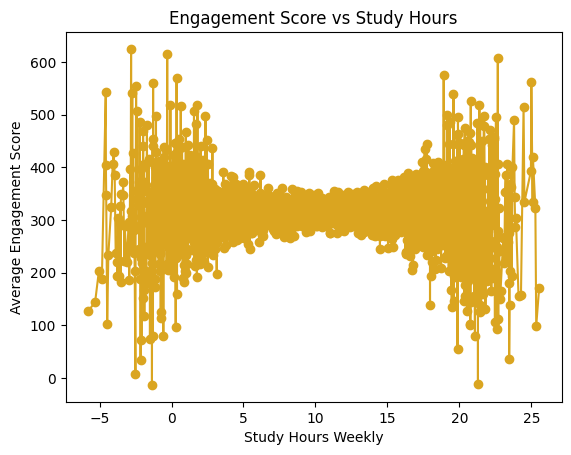

In [15]:
# Group and sort
line_data = df.groupby('study_hours_weekly')['engagement_score'].mean().sort_index()

line_data.plot(kind='line', marker='o',color='goldenrod')

plt.title("Engagement Score vs Study Hours")
plt.xlabel("Study Hours Weekly")
plt.ylabel("Average Engagement Score")
plt.show()

The line graph shows a general upward trend, indicating that students who spend more time studying tend to have higher engagement levels. This suggests a positive relationship between effort and participation.

A line graph used as:
Best for showing trend or progression
Works well when data is ordered (like study hours)


A bar plot is not used as bar plot doesn’t show smooth trends


Scatter shows individual points, not overall trend hence it is also not used

**Q16. What is the distribution pattern of students’ weekly study hours**

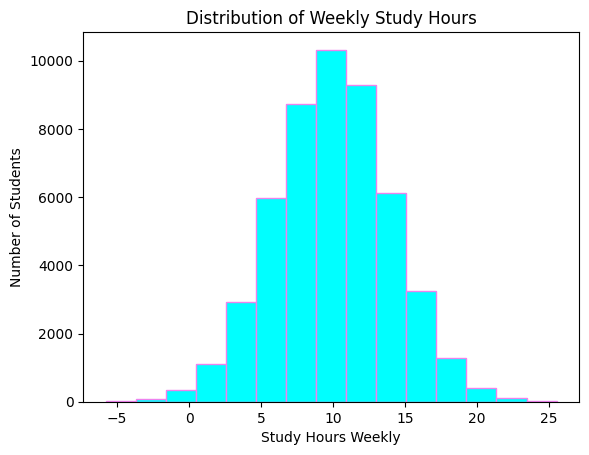

In [16]:
plt.hist(df['study_hours_weekly'],color='cyan',bins=15,edgecolor='violet')
plt.title("Distribution of Weekly Study Hours")
plt.xlabel("Study Hours Weekly")
plt.ylabel("Number of Students")
plt.show()

The histogram shows that most students fall within a moderate study range, with fewer students studying extremely low or high hours. This indicates that average study behavior is concentrated around the middle range.

Histogram used as itsL
Best for understanding distribution and frequency
Shows concentration of values

Boxplot and line graph not used as:
Boxplot shows spread and outliers but not frequency
Line graph is for trends, not distributions

**Q17. Top 10 students by final grade**

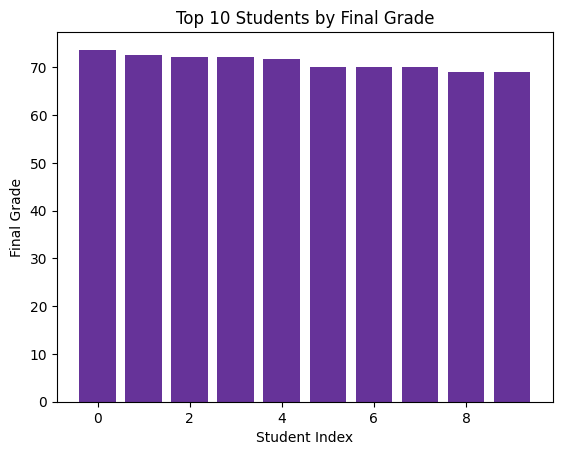

       student_id  age  gender    country device_type  internet_speed_mbps  \
26410       26411   24    Male    Germany      Mobile                47.75   
48962       48963   44    Male  Australia      Tablet                81.51   
43884       43885   37    Male      India      Mobile                31.71   
18310       18311   28  Female         UK      Tablet                44.68   
44588       44589   43    Male     Canada      Mobile                76.78   
11300       11301   40    Male    Germany      Mobile                63.62   
14047       14048   30  Female    Germany      Laptop                57.42   
33610       33611   30    Male      India      Laptop                57.84   
47790       47791   44  Female  Australia      Tablet                42.78   
16455       16456   32  Female     Canada      Laptop                14.95   

       study_hours_weekly  login_frequency_weekly  avg_session_duration_min  \
26410               10.96                       4             

In [17]:
top10 = df.sort_values(by='final_grade', ascending=False).head(10)

plt.figure()
plt.bar(range(len(top10)), top10['final_grade'],color='rebeccapurple')

plt.title("Top 10 Students by Final Grade")
plt.xlabel("Student Index")
plt.ylabel("Final Grade")
plt.show()

print(top10)

**Q18. How is the distribution and density of final grades spread across different genders?**

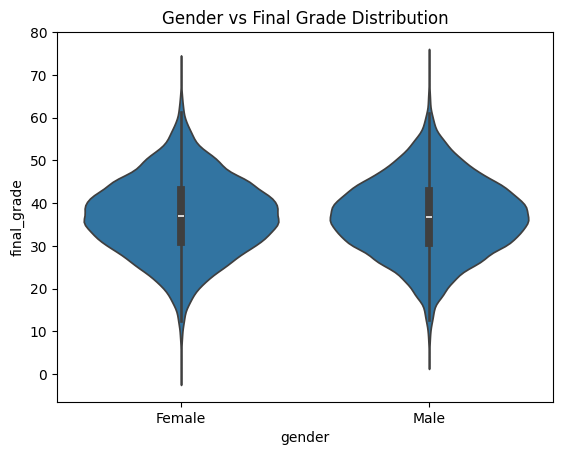

In [18]:
sns.violinplot(x='gender', y='final_grade', data=df)
plt.title("Gender vs Final Grade Distribution")
plt.show()